In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import fashion_mnist

In [2]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# reshape for CNN
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training shape:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28, 1)


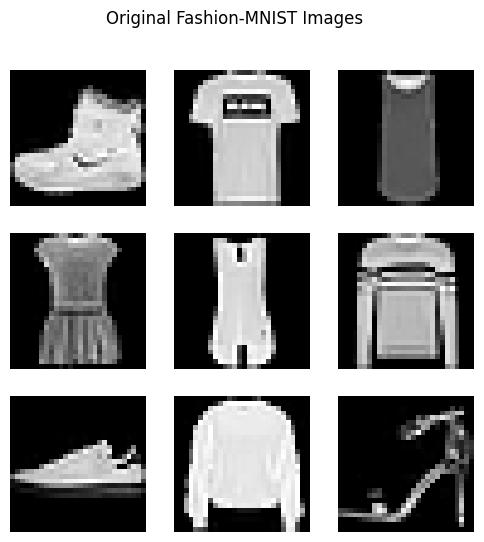

In [3]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original Fashion-MNIST Images")
plt.show()

In [4]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

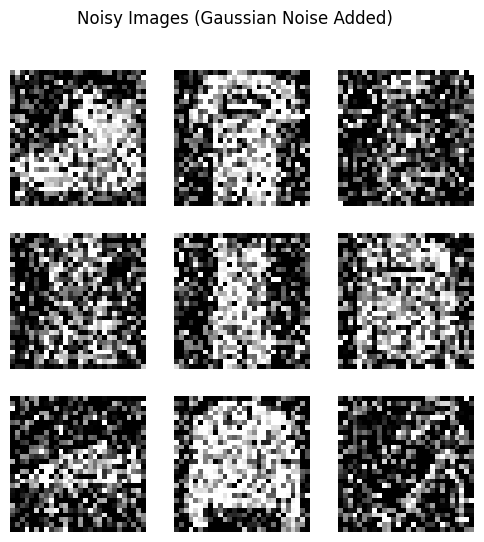

In [5]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Noisy Images (Gaussian Noise Added)")
plt.show()

In [6]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.4061 - val_loss: 0.3162
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3111 - val_loss: 0.3095
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3064 - val_loss: 0.3067
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3034 - val_loss: 0.3050
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3014 - val_loss: 0.3030
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3009 - val_loss: 0.3019
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2995 - val_loss: 0.3010
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2989 - val_loss: 0.3002
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2979 - val_loss: 0.2997
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2970 - val_loss: 0.2990


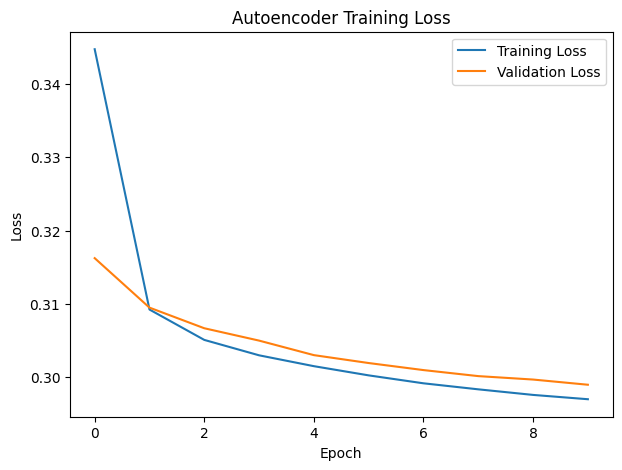

In [8]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


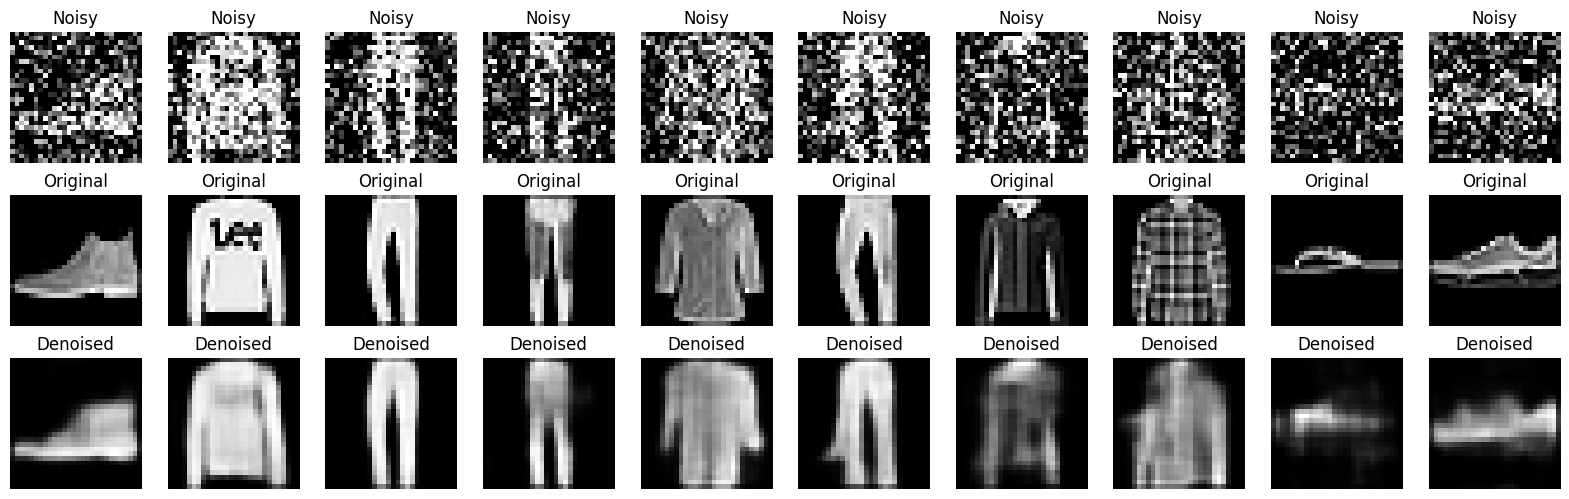

In [10]:
n = 10
plt.figure(figsize=(20,6))

for i in range(n):

    # Noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Clean
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.show()

# **Autoencoder Exercise 2: Credit Card Fraud Anomaly Detection**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [2]:
df = pd.read_csv("creditcard.csv")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


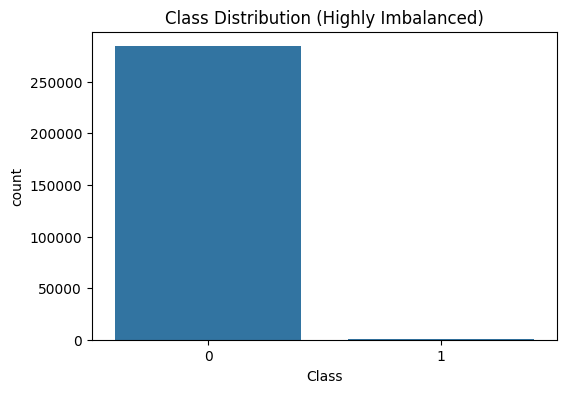

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Class"])
plt.title("Class Distribution (Highly Imbalanced)")
plt.show()

In [5]:
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df["Amount"].values.reshape(-1,1))

df = df.drop(["Time"], axis=1)

In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
X_train_normal = X_train[y_train == 0]

In [8]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)

decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │           493 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,253 (4.89 KB)

 Trainable params: 1,253 (4.89 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.8718 - val_loss: 0.5044
Epoch 2/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4671 - val_loss: 0.4202
Epoch 3/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4020 - val_loss: 0.3842
Epoch 4/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3721 - val_loss: 0.3738
Epoch 5/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3622 - val_loss: 0.3595
Epoch 6/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3537 - val_loss: 0.3512
Epoch 7/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3446 - val_loss: 0.3464
Epoch 8/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3368 - val_loss: 0.3396
Epoch 9/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3340 - val_loss: 0.3367
Epoch 10/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3303 - val_loss: 0.3327


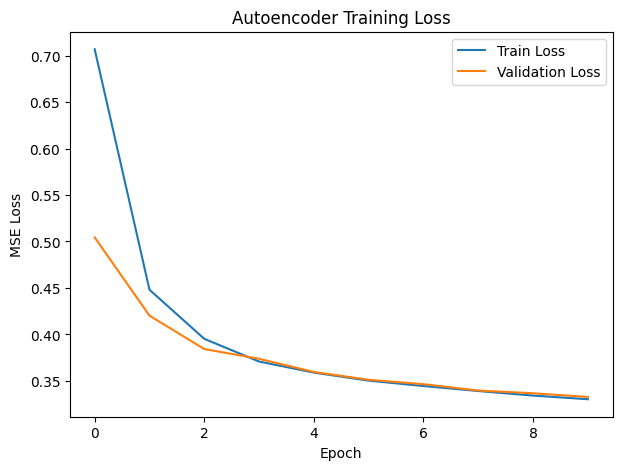

In [10]:
plt.figure(figsize=(7,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.show()

In [11]:
X_test_pred = autoencoder.predict(X_test)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [12]:
mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

error_df = pd.DataFrame({
    "reconstruction_error": mse,
    "true_class": y_test
})

error_df.head()

,reconstruction_error,true_class
43428,58.783167,1
49906,0.438352,0
29474,0.223442,0
276481,0.208248,0
278846,0.111359,0


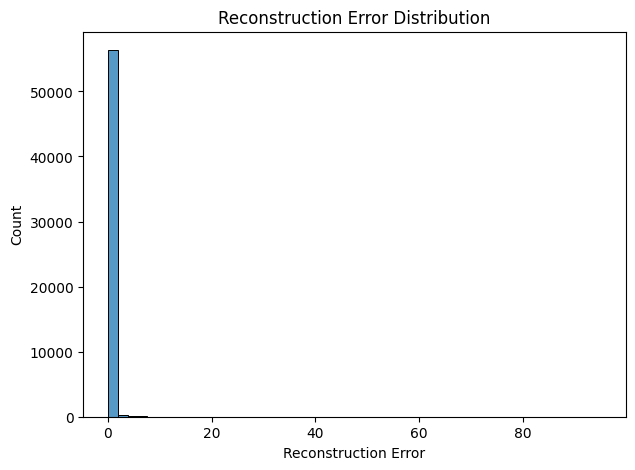

In [13]:
plt.figure(figsize=(7,5))

sns.histplot(error_df["reconstruction_error"], bins=50)

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.show()

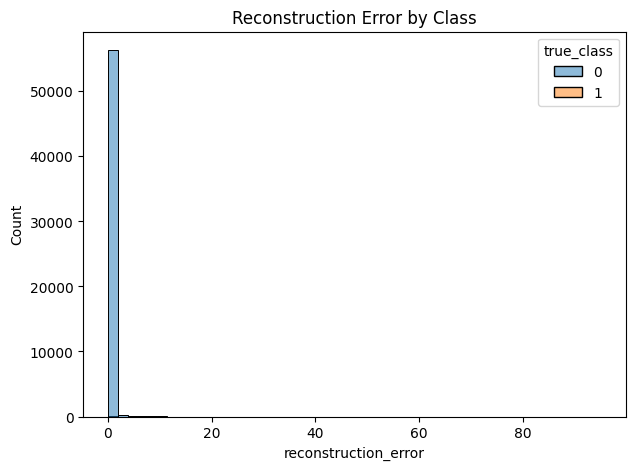

In [14]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=error_df,
    x="reconstruction_error",
    hue="true_class",
    bins=50
)

plt.title("Reconstruction Error by Class")
plt.show()

In [15]:
threshold = error_df["reconstruction_error"].quantile(0.95)

print("Threshold:", threshold)

Threshold: 0.7648767551509265


In [16]:
y_pred = error_df["reconstruction_error"] > threshold

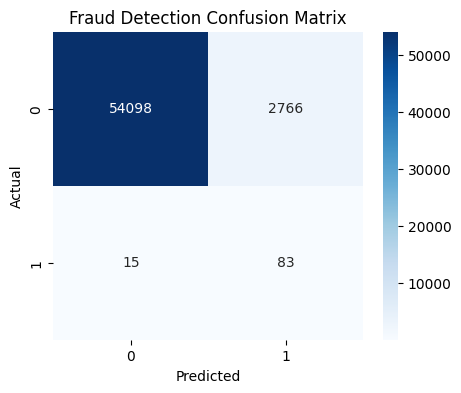

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Detection Confusion Matrix")

plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.85      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.90      0.52     56962
weighted avg       1.00      0.95      0.97     56962



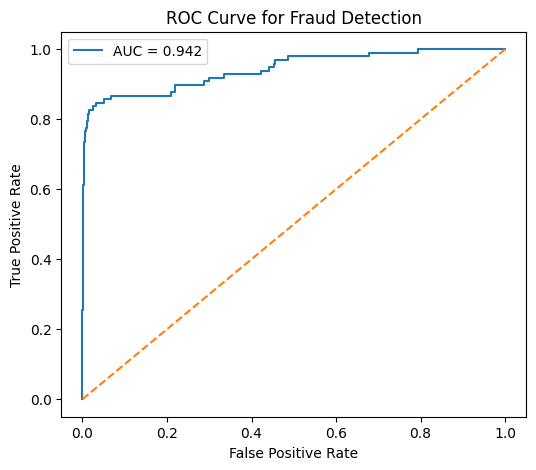

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, mse)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="AUC = %0.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Fraud Detection")

plt.legend()
plt.show()

# **Exercise 3: Dimensionality Reduction using Autoencoder vs PCA**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [21]:
columns = [
'id','diagnosis',
'mean_radius','mean_texture','mean_perimeter','mean_area','mean_smoothness',
'mean_compactness','mean_concavity','mean_concave_points','mean_symmetry','mean_fractal_dimension',
'radius_se','texture_se','perimeter_se','area_se','smoothness_se','compactness_se',
'concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',
'worst_radius','worst_texture','worst_perimeter','worst_area','worst_smoothness',
'worst_compactness','worst_concavity','worst_concave_points','worst_symmetry','worst_fractal_dimension'
]

df = pd.read_csv("wdbc.data", names=columns)

df.head()

,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [22]:
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

In [23]:
X = df.drop(["id","diagnosis"], axis=1)
y = df["diagnosis"]

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

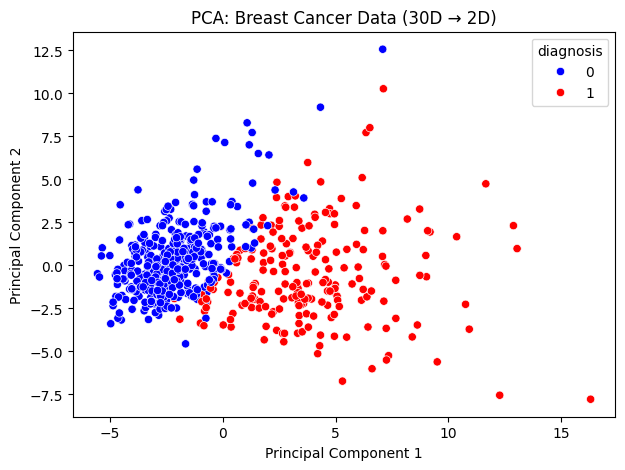

In [26]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette=["blue","red"]
)

plt.title("PCA: Breast Cancer Data (30D → 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [27]:
input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(16, activation="relu")(input_layer)
encoder = Dense(8, activation="relu")(encoder)

bottleneck = Dense(2, activation="linear")(encoder)

decoder = Dense(8, activation="relu")(bottleneck)
decoder = Dense(16, activation="relu")(decoder)

output = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=output)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,328 (5.19 KB)

 Trainable params: 1,328 (5.19 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - loss: 0.9436 - val_loss: 0.9261
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9457 - val_loss: 0.8704
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8934 - val_loss: 0.8175
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7699 - val_loss: 0.7770
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8180 - val_loss: 0.7402
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7336 - val_loss: 0.7117
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7138 - val_loss: 0.6876
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6923 - val_loss: 0.6651
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6397 - val_loss: 0.6391
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6389 - val_loss: 0.6130
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6530 - val_loss: 0.5970
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5816 - v

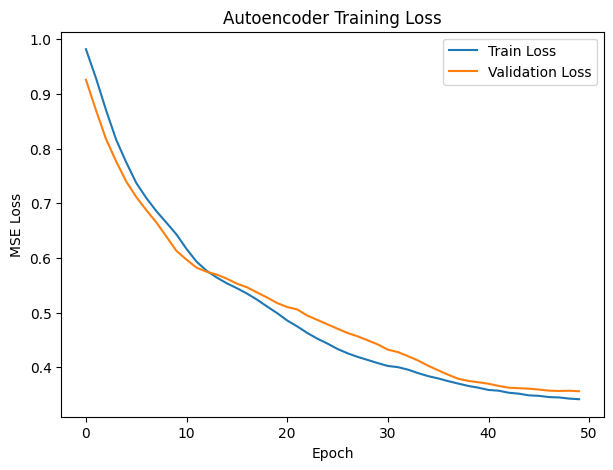

In [29]:
plt.figure(figsize=(7,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

In [30]:
encoder_model = Model(inputs=input_layer, outputs=bottleneck)

X_encoded = encoder_model.predict(X_scaled)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


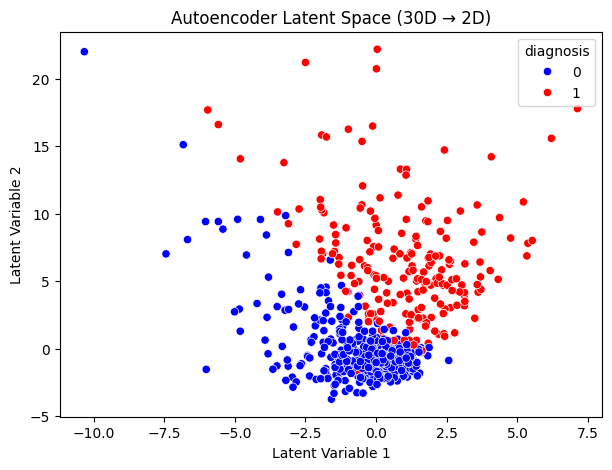

In [31]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_encoded[:,0],
    y=X_encoded[:,1],
    hue=y,
    palette=["blue","red"]
)

plt.title("Autoencoder Latent Space (30D → 2D)")
plt.xlabel("Latent Variable 1")
plt.ylabel("Latent Variable 2")

plt.show()

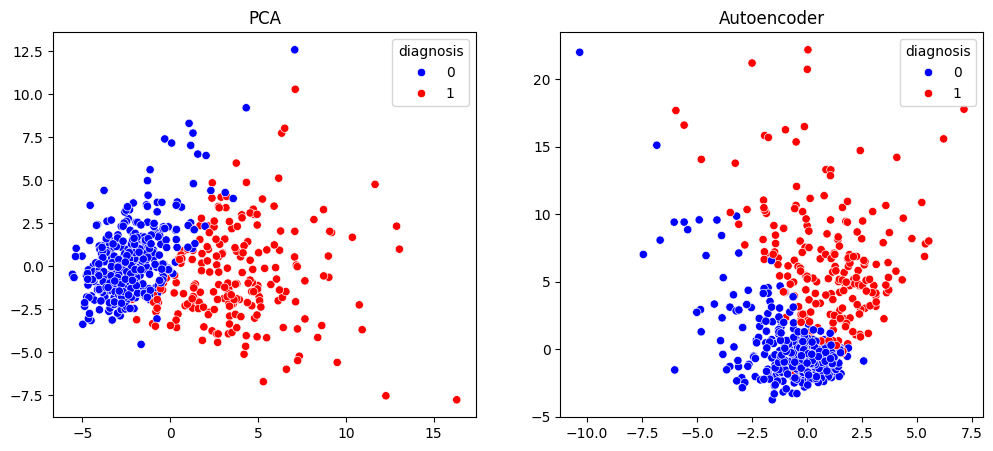

In [32]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette=["blue","red"],
    ax=axes[0]
)

axes[0].set_title("PCA")

sns.scatterplot(
    x=X_encoded[:,0],
    y=X_encoded[:,1],
    hue=y,
    palette=["blue","red"],
    ax=axes[1]
)

axes[1].set_title("Autoencoder")

plt.show()

# **1. Variational Autoencoder (VAE) – Synthetic Medical Data Generation**

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras import backend as K

In [34]:
df = pd.read_csv("diabetes.csv")

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
X = df.drop("Outcome", axis=1)

print(X.shape)

(768, 8)


In [36]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

<Figure size 1200x800 with 0 Axes>

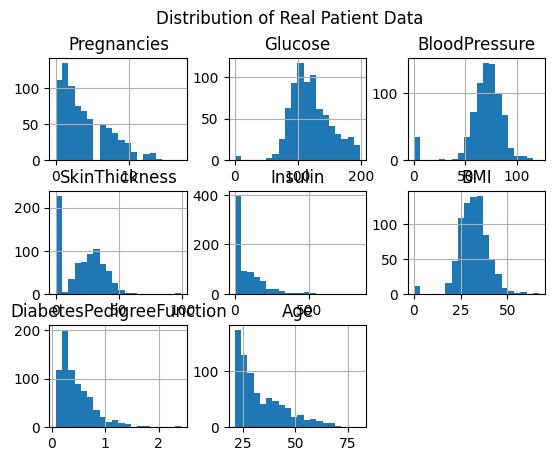

In [37]:
plt.figure(figsize=(12,8))

df.drop("Outcome",axis=1).hist(bins=20)
plt.suptitle("Distribution of Real Patient Data")

plt.show()

In [38]:
latent_dim = 2

def sampling(args):

    z_mean, z_log_var = args

    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))

    return z_mean + K.exp(0.5 * z_log_var) * epsilon

In [39]:
input_dim = X_scaled.shape[1]

inputs = Input(shape=(input_dim,))

h = Dense(16, activation="relu")(inputs)
h = Dense(8, activation="relu")(h)

z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)

z = Lambda(sampling)([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

In [40]:
latent_inputs = Input(shape=(latent_dim,))

x = Dense(8, activation="relu")(latent_inputs)
x = Dense(16, activation="relu")(x)

outputs = Dense(input_dim, activation="linear")(x)

decoder = Model(latent_inputs, outputs)

In [41]:
outputs = decoder(z)

vae = Model(inputs, outputs)

In [52]:
from tensorflow.keras.layers import Layer
import tensorflow as tf

class Sampling(Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [53]:
input_dim = X_scaled.shape[1]
latent_dim = 2

inputs = Input(shape=(input_dim,))

x = Dense(16, activation="relu")(inputs)
x = Dense(8, activation="relu")(x)

z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

In [54]:
latent_inputs = Input(shape=(latent_dim,))

x = Dense(8, activation="relu")(latent_inputs)
x = Dense(16, activation="relu")(x)

outputs = Dense(input_dim)(x)

decoder = Model(latent_inputs, outputs)

In [55]:
outputs = decoder(z)

vae = Model(inputs, outputs)

In [63]:
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

In [64]:
vae.fit(
    X_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - loss: 1.1971 - val_loss: 1.0153
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1320 - val_loss: 0.9915
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0633 - val_loss: 0.9546
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0431 - val_loss: 0.9546
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9879 - val_loss: 0.9508
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0616 - val_loss: 0.9449
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0520 - val_loss: 0.9441
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0586 - val_loss: 0.9436
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0548 - val_loss: 0.9409
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9778 - val_loss: 0.9382
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0265 - val_loss: 0.9359
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1

In [61]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        reconstruction_loss = mse(inputs, reconstruction)
        reconstruction_loss = tf.keras.ops.mean(reconstruction_loss)

        kl_loss = -0.5 * tf.keras.ops.mean(
            1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var)
        )
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)

        return reconstruction

In [58]:
!pip install tensorflow

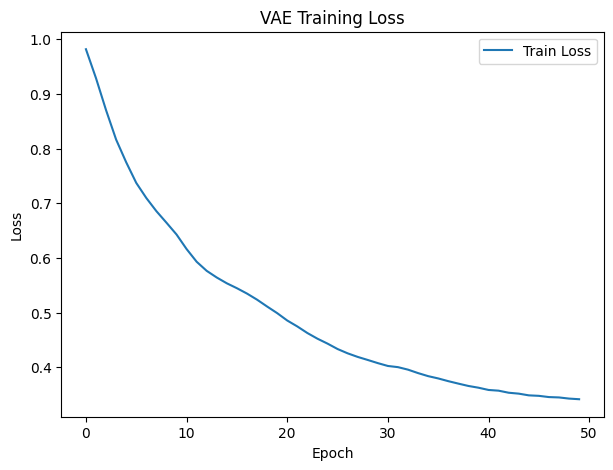

In [66]:
plt.figure(figsize=(7,5))

plt.plot(history.history["loss"], label="Train Loss")

plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [67]:
num_samples = 200

random_latent = np.random.normal(size=(num_samples, latent_dim))

synthetic_data = decoder.predict(random_latent)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


In [68]:
synthetic_data = scaler.inverse_transform(synthetic_data)

synthetic_df = pd.DataFrame(synthetic_data, columns=X.columns)

synthetic_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,3.795918,120.219238,68.492798,20.653030,79.873375,31.867926,0.480683,33.254860
1,3.778400,119.962875,68.291702,20.538055,79.908363,31.930019,0.481674,33.173607
2,3.678303,121.554207,67.836212,20.684624,74.193565,32.015385,0.490482,33.489101
3,3.795918,120.219238,68.492798,20.653030,79.873375,31.867926,0.480683,33.254860
4,3.795918,120.219238,68.492798,20.653030,79.873375,31.867926,0.480683,33.254860


<Figure size 1200x800 with 0 Axes>

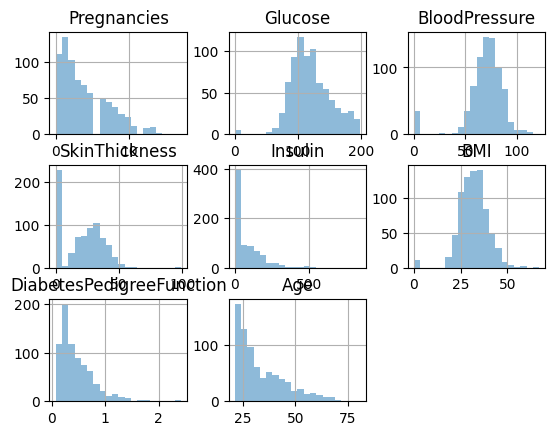

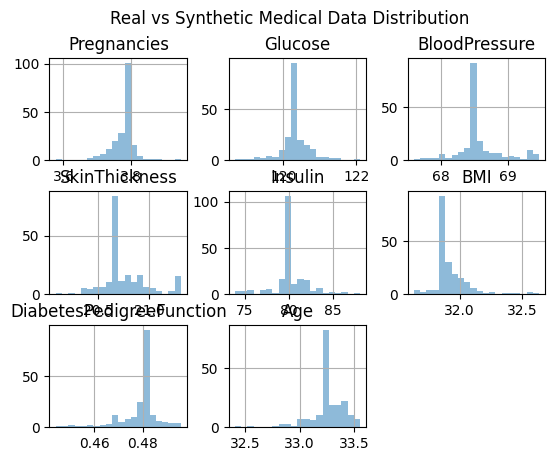

In [69]:
plt.figure(figsize=(12,8))

X.hist(bins=20, alpha=0.5, label="Real")

synthetic_df.hist(bins=20, alpha=0.5, label="Synthetic")

plt.suptitle("Real vs Synthetic Medical Data Distribution")

plt.show()

In [70]:
print("Synthetic Patient Data")

synthetic_df.sample(10)

Synthetic Patient Data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
54,3.762168,119.227768,68.173866,20.437851,82.017220,32.086983,0.475431,32.850983
159,3.795918,120.219238,68.492798,20.653030,79.873375,31.867926,0.480683,33.254860
197,3.775196,120.037895,68.869034,20.928553,81.849007,32.072720,0.467683,33.137772
161,3.792028,120.162323,68.448151,20.627504,79.881142,31.881712,0.480903,33.236820
10,3.795918,120.219238,68.492798,20.653030,79.873375,31.867926,0.480683,33.254860
150,3.795918,120.219238,68.492798,20.653030,79.873375,31.867926,0.480683,33.254860
127,3.755084,119.621635,68.024048,20.385019,79.954926,32.012672,0.482993,33.065456
68,3.706705,120.065277,69.330154,21.259253,82.827164,32.581604,0.450044,33.028748
105,3.795918,120.219238,68.492798,20.653030,79.873375,31.867926,0.480683,33.254860
121,3.721028,121.123863,67.825233,20.354033,75.012070,31.966923,0.494221,33.383156


# **Variational Autoencoder Exercise 2: Artificial Face Generation (CelebA)**

In [71]:
!pip install kaggle

In [72]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"srajankushwaha","key":"8a8eec217fb02b689923d019df5cdf4e"}'}

In [73]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [74]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
 99% 1.32G/1.33G [00:12<00:00, 70.2MB/s]
100% 1.33G/1.33G [00:12<00:00, 115MB/s] 


In [75]:
!unzip celeba-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: img_align_celeba/img_align_celeba/197604.jpg  
  inflating: img_align_celeba/img_align_celeba/197605.jpg  
  inflating: img_align_celeba/img_align_celeba/197606.jpg  
  inflating: img_align_celeba/img_align_celeba/197607.jpg  
  inflating: img_align_celeba/img_align_celeba/197608.jpg  
  inflating: img_align_celeba/img_align_celeba/197609.jpg  
  inflating: img_align_celeba/img_align_celeba/197610.jpg  
  inflating: img_align_celeba/img_align_celeba/197611.jpg  
  inflating: img_align_celeba/img_align_celeba/197612.jpg  
  inflating: img_align_celeba/img_align_celeba/197613.jpg  
  inflating: img_align_celeba/img_align_celeba/197614.jpg  
  inflating: img_align_celeba/img_align_celeba/197615.jpg  
  inflating: img_align_celeba/img_align_celeba/197616.jpg  
  inflating: img_align_celeba/img_align_celeba/197617.jpg  
  inflating: img_align_celeba/img_align_celeba/197618.jpg  
  inflating: img_align_celeba/img_align_celeba/19

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [86]:
IMAGE_SIZE = 64
DATASET_PATH = "/content/img_align_celeba/img_align_celeba"

images = []

files = os.listdir(DATASET_PATH)[:20000]

for f in files:

    img = load_img(os.path.join(DATASET_PATH,f),
                   target_size=(IMAGE_SIZE,IMAGE_SIZE))

    img = img_to_array(img)/255.0

    images.append(img)

X = np.array(images)

print("Dataset shape:", X.shape)

Dataset shape: (20000, 64, 64, 3)


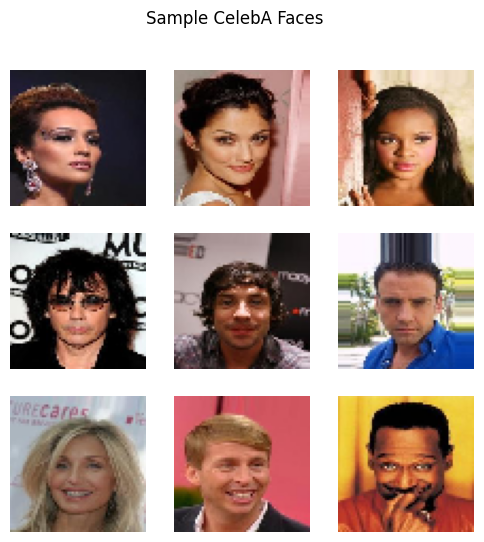

In [87]:
plt.figure(figsize=(6,6))

for i in range(9):

    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.axis("off")

plt.suptitle("Sample CelebA Faces")

plt.show()

In [88]:
latent_dim = 128

In [89]:
encoder_input = Input(shape=(64,64,3))

x = Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_input)
x = Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
x = Conv2D(128,3,strides=2,padding="same",activation="relu")(x)

x = Flatten()(x)
x = Dense(256,activation="relu")(x)

z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

In [90]:
def sampling(args):

    z_mean, z_log_var = args

    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))

    return z_mean + tf.exp(0.5*z_log_var)*epsilon

z = Lambda(sampling)([z_mean,z_log_var])

In [91]:
decoder_input = Input(shape=(latent_dim,))

x = Dense(8*8*128,activation="relu")(decoder_input)

x = Reshape((8,8,128))(x)

x = Conv2DTranspose(128,3,strides=2,padding="same",activation="relu")(x)
x = Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
x = Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)

decoder_output = Conv2DTranspose(3,3,padding="same",activation="sigmoid")(x)

decoder = Model(decoder_input,decoder_output)

In [92]:
encoder = Model(encoder_input,[z_mean,z_log_var,z])

outputs = decoder(z)

vae = Model(encoder_input,outputs)

In [95]:
class CVAE(tf.keras.Model):
    def __init__(self, encoder_model, decoder_model, **kwargs):
        super().__init__(**kwargs)
        self.encoder_model = encoder_model
        self.decoder_model = decoder_model

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder_model(inputs)
        reconstruction = self.decoder_model(z)

        # Reconstruction loss (binary_crossentropy for images)
        reconstruction_loss = tf.keras.ops.binary_crossentropy(inputs, reconstruction)
        reconstruction_loss = tf.keras.ops.mean(reconstruction_loss) * IMAGE_SIZE * IMAGE_SIZE * 3 # Scale to match pixel-wise sum

        # KL Divergence loss
        kl_loss = -0.5 * tf.keras.ops.mean(
            1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var)
        )

        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)

        return reconstruction

# Instantiate the custom CVAE model with the functional encoder and decoder
cvae_model = CVAE(encoder_model=encoder, decoder_model=decoder)

# Compile the CVAE model
cvae_model.compile(optimizer="adam")

cvae_model.summary()

Model: "cvae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_10 (Functional)      │ ((None, 128), (None,   │     2,256,448 │
│                                 │ 128), (None, 128))     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_9 (Functional)       │ (None, 64, 64, 3)      │     1,297,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,553,923 (13.56 MB)

 Trainable params: 3,553,923 (13.56 MB)

 Non-trainable params: 0 (0.00 B)

In [97]:
history = cvae_model.fit(
    X,
    epochs=20,
    batch_size=64,
    shuffle=True
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 7507.6562
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 6436.1313
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6294.2051
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6229.4331
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6198.7378
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6171.0430
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6150.5342
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6146.6040
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 6122.3242
Epoch 10/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6109.6992
Epoch 11/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6112.5444
Epoch 12/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6103.7559
Epoch 13/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 6090.1870
Epoch 14/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6093.6538


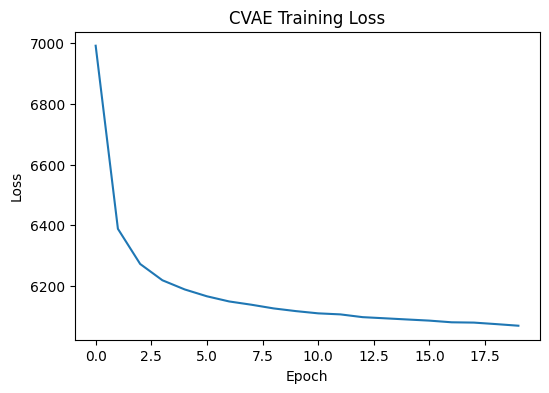

In [98]:
plt.figure(figsize=(6,4))

plt.plot(history.history["loss"])

plt.title("CVAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [99]:
n = 9

random_latent = np.random.normal(size=(n,latent_dim))

generated_faces = decoder.predict(random_latent)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step


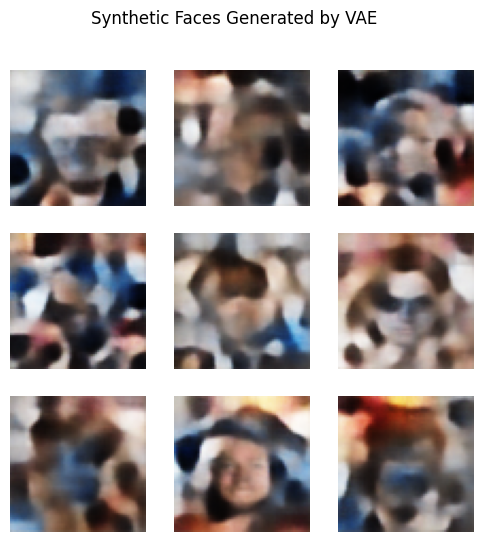

In [100]:
plt.figure(figsize=(6,6))

for i in range(n):

    plt.subplot(3,3,i+1)
    plt.imshow(generated_faces[i])
    plt.axis("off")

plt.suptitle("Synthetic Faces Generated by VAE")

plt.show()

In [101]:
face_A = X[0:1]
face_B = X[1:2]

zA_mean,_,_ = encoder.predict(face_A)
zB_mean,_,_ = encoder.predict(face_B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [102]:
steps = 10

faces = []

for alpha in np.linspace(0,1,steps):

    z_interp = (1-alpha)*zA_mean + alpha*zB_mean

    face = decoder.predict(z_interp)

    faces.append(face[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


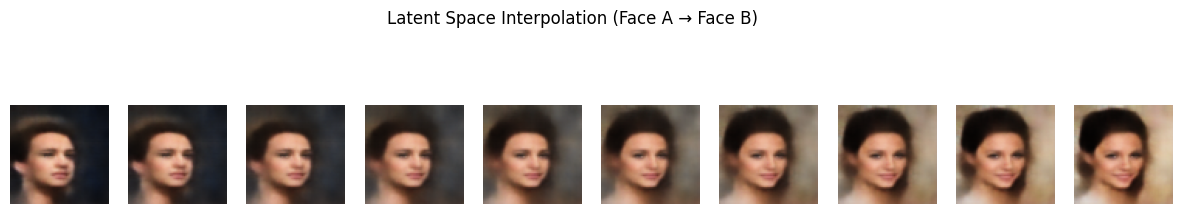

In [103]:
plt.figure(figsize=(15,3))

for i in range(steps):

    plt.subplot(1,steps,i+1)
    plt.imshow(faces[i])
    plt.axis("off")

plt.suptitle("Latent Space Interpolation (Face A → Face B)")

plt.show()

# **Exercise 3: Molecular Discovery (Drug Design)**

In [10]:
!pip install rdkit
!pip install deepchem

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 21.0 MB/s eta 0:00:00


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

from rdkit import Chem
from rdkit.Chem import Draw

In [12]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/qm9.csv"

df = pd.read_csv(url)

print(df.shape)

df.head()

(133885, 21)


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


In [13]:
smiles = df["smiles"].values[:50000]   # limit for faster training

print(smiles[:10])

['C' 'N' 'O' 'C#C' 'C#N' 'C=O' 'CC' 'CO' 'CC#C' 'CC#N']


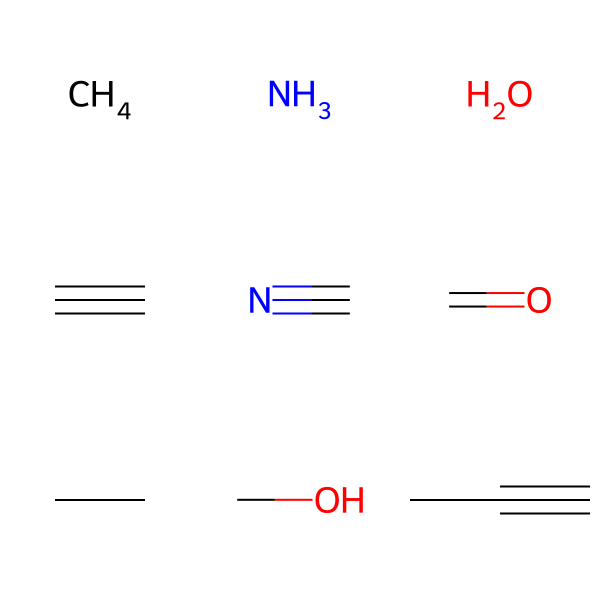

In [14]:
mols = [Chem.MolFromSmiles(s) for s in smiles[:9]]

Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(200,200))

In [15]:
chars = sorted(list(set("".join(smiles))))

print(chars)

['#', '(', ')', '+', '-', '1', '2', '3', '4', '5', '=', 'C', 'F', 'H', 'N', 'O', '[', ']', 'c', 'n', 'o']


In [16]:
char_to_int = {c:i for i,c in enumerate(chars)}
int_to_char = {i:c for c,i in char_to_int.items()}

vocab_size = len(chars)

print("Vocabulary size:", vocab_size)

Vocabulary size: 21


In [17]:
max_len = max(len(s) for s in smiles)

print("Max length:", max_len)

Max length: 29


In [18]:
encoded = np.zeros((len(smiles), max_len))

for i,sm in enumerate(smiles):

    for j,ch in enumerate(sm):

        encoded[i,j] = char_to_int[ch]

encoded.shape

(50000, 29)

In [19]:
encoded = encoded / vocab_size

In [20]:
latent_dim = 64

inputs = Input(shape=(max_len,1))

x = LSTM(128)(inputs)

z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

In [21]:
def sampling(args):

    z_mean, z_log_var = args

    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))

    return z_mean + tf.exp(0.5*z_log_var)*epsilon

z = Lambda(sampling)([z_mean,z_log_var])

In [22]:
decoder_input = Input(shape=(latent_dim,))

x = RepeatVector(max_len)(decoder_input)

x = LSTM(128, return_sequences=True)(x)

outputs = TimeDistributed(Dense(vocab_size, activation="softmax"))(x)

decoder = Model(decoder_input, outputs)

In [23]:
encoder = Model(inputs, [z_mean, z_log_var, z])

outputs = decoder(z)

vae = Model(inputs, outputs)

In [24]:
class SmilesVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(SmilesVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.keras.losses.sparse_categorical_crossentropy(inputs, reconstruction)
        reconstruction_loss = tf.keras.ops.mean(reconstruction_loss)

        kl_loss = -0.5 * tf.keras.ops.mean(
            1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var)
        )
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)

        return reconstruction

smiles_vae_model = SmilesVAE(encoder, decoder)
smiles_vae_model.compile(optimizer="adam")

smiles_vae_model.summary()

Model: "smiles_vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_1 (Functional)       │ ((None, 64), (None,    │        83,072 │
│                                 │ 64), (None, 64))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 29, 21)         │       101,525 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,597 (721.08 KB)

 Trainable params: 184,597 (721.08 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
X = encoded.reshape(encoded.shape[0], encoded.shape[1],1)

history = smiles_vae_model.fit(
    X,
    epochs=50,
    batch_size=128
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.4842
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0451
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0211
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0082
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0023
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 5.7326e-04
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 2.4801e-04
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 1.4204e-04
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 9.5357e-05
Epoch 10/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.7950e-05
Epoch 11/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.0395e-05
Epoch 12/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.8804e-05
Epoch 13/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.0304e-05
Epoch 14/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 2.4062e-05
Epoc

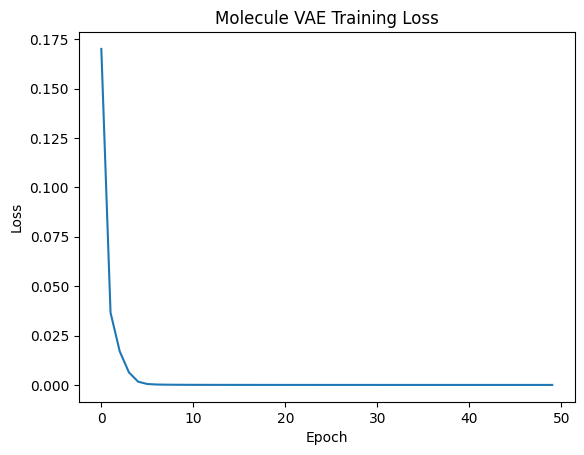

In [35]:
plt.plot(history.history["loss"])

plt.title("Molecule VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [36]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Lambda, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model

# 1. Define functional Encoder
inputs = Input(shape=(max_len, 1))
x = LSTM(128)(inputs)
latent_dim = 64
z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling)([z_mean, z_log_var])
encoder = Model(inputs, [z_mean, z_log_var, z])

# 2. Define functional Decoder
decoder_input = Input(shape=(latent_dim,))
x = RepeatVector(max_len)(decoder_input)
x = LSTM(128, return_sequences=True)(x)
outputs = TimeDistributed(Dense(vocab_size, activation="softmax"))(x)
decoder = Model(decoder_input, outputs)

# 3. Define SmilesVAE Class
class SmilesVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(SmilesVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.keras.losses.sparse_categorical_crossentropy(inputs, reconstruction)
        reconstruction_loss = tf.keras.ops.mean(reconstruction_loss)
        kl_loss = -0.5 * tf.keras.ops.mean(
            1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var)
        )
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)
        return reconstruction

# 4. Instantiate and Predict
smiles_vae_model = SmilesVAE(encoder, decoder)
smiles_vae_model.compile(optimizer="adam")

n = 10
latent_samples = np.random.normal(size=(n, latent_dim))
generated = smiles_vae_model.decoder.predict(latent_samples)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step


In [37]:
generated_smiles = []

for g in generated:

    seq = np.argmax(g,axis=1)

    sm = "".join(int_to_char[i] for i in seq)

    generated_smiles.append(sm)

generated_smiles

['ooooooooooooooooooooooooooooo',
 ')))))))))))))))))))))))))))))',
 '[[[[[[[[[[[[[[[[[[[[[[[[[[[[[',
 'FFFFFFFFFFFFFFFFFFFFFFFFFFFFF',
 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCC',
 '===############CCCCCCCCCCCCCC',
 ']]]CCCCCCCCCCCCCCCCCCCCCCCCCC',
 'HHHHHHHHHHHHHHHHHHHHHHHHHHHHH',
 '====-------------------------',
 'H+++HHHHHHH##################']

[08:44:26] non-ring atom 0 marked aromatic
[08:44:26] SMILES Parse Error: syntax error while parsing: )))))))))))))))))))))))))))))
[08:44:26] SMILES Parse Error: check for mistakes around position 1:
[08:44:26] )))))))))))))))))))))))))))))
[08:44:26] ^
[08:44:26] SMILES Parse Error: Failed parsing SMILES ')))))))))))))))))))))))))))))' for input: ')))))))))))))))))))))))))))))'
[08:44:26] SMILES Parse Error: syntax error while parsing: [[[[[[[[[[[[[[[[[[[[[[[[[[[[[
[08:44:26] SMILES Parse Error: check for mistakes around position 2:
[08:44:26] [[[[[[[[[[[[[[[[[[[[[[[[[[[[[
[08:44:26] ~^
[08:44:26] SMILES Parse Error: Failed parsing SMILES '[[[[[[[[[[[[[[[[[[[[[[[[[[[[[' for input: '[[[[[[[[[[[[[[[[[[[[[[[[[[[[['
[08:44:26] Explicit valence for atom # 1 F, 2, is greater than permitted
[08:44:26] SMILES Parse Error: syntax error while parsing: ===############CCCCCCCCCCCCCC
[08:44:26] SMILES Parse Error: check for mistakes around position 1:
[08:44:26] ===############CCCCCCCCCCCCCC
[08:

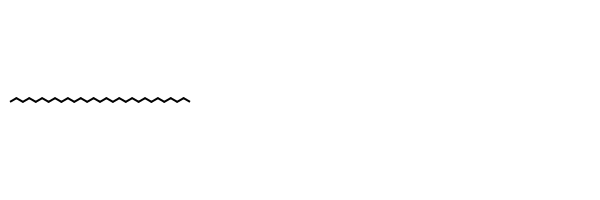

In [38]:
molecules = []

for s in generated_smiles:

    mol = Chem.MolFromSmiles(s)

    if mol:
        molecules.append(mol)

Draw.MolsToGridImage(molecules[:9], molsPerRow=3, subImgSize=(200,200))

In [39]:
print("Generated SMILES strings:")
display(generated_smiles)

Generated SMILES strings:


['ooooooooooooooooooooooooooooo',
 ')))))))))))))))))))))))))))))',
 '[[[[[[[[[[[[[[[[[[[[[[[[[[[[[',
 'FFFFFFFFFFFFFFFFFFFFFFFFFFFFF',
 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCC',
 '===############CCCCCCCCCCCCCC',
 ']]]CCCCCCCCCCCCCCCCCCCCCCCCCC',
 'HHHHHHHHHHHHHHHHHHHHHHHHHHHHH',
 '====-------------------------',
 'H+++HHHHHHH##################']

In [40]:
mol = X[0:1]

z_mean,_,_ = encoder.predict(mol)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


In [42]:
variations = []

for i in np.linspace(-1,1,10):

    z_new = z_mean + i

    sm = decoder.predict(z_new)

    seq = np.argmax(sm[0],axis=1)

    variations.append("".join(int_to_char[x] for x in seq))

variations

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


['CCCCCCCCCOOOOOOOOOOOOOOOOOOOO',
 'CCCCCCCCCCCOOOOOOOOOOOOOOOOOO',
 'CCCCCCCCCCCCCCCCCCCCCCOOOOOOO',
 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCC',
 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCC',
 '22222222222222222222222222222',
 '22222222222222222222222222222',
 '22222222222222222222222222222',
 '22222222222222222222222222222',
 '22222222222222222222222222222']